In [26]:
train_data_location = "../data/train"
test_data_location = "../data/test"
val_data_location = "../data/val"

In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [28]:
# Preprocessing and Data Augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [29]:
train_data = datasets.ImageFolder("../data/train", transform=train_transform)
val_data = datasets.ImageFolder("../data/val", transform=val_test_transform)
test_data = datasets.ImageFolder("../data/test", transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(train_data.class_to_idx)

{'overripe': 0, 'ripe': 1, 'spotty': 2, 'underripe': 3}


In [30]:
# Define a simple CNN model
class BananaNet(nn.Module):
    def __init__(self, num_classes=4):
        super(BananaNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 112x112
        x = self.pool(F.relu(self.conv2(x))) # 56x56
        x = x.view(-1, 32 * 56 * 56) # Flatten
        x = F.relu(self.fc1(x)) # 32x56x56 -> 128
        x = self.dropout(x)
        x = self.fc2(x) # 128 -> num_classes
        return x

model = BananaNet().to(device)

In [31]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Define a function to evaluate the model
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [ ]:
epochs = 20 # Custom model needs more epochs than mobilenet
best_val_acc = 0.0

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()

    # Validation Phase
    val_loss, val_acc = evaluate_model(model, val_loader)
    
    print(f"Epoch {epoch+1}/{epochs} -> "
          f"Train Loss: {running_train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save the best version of the model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../saved_models/BananaNet.pth')


Epoch 1/20 -> Train Loss: 5.9625 | Val Loss: 1.3161 | Val Acc: 26.47%
Epoch 2/20 -> Train Loss: 2.1512 | Val Loss: 1.2410 | Val Acc: 26.47%
Epoch 3/20 -> Train Loss: 1.4164 | Val Loss: 1.3540 | Val Acc: 32.35%
Epoch 4/20 -> Train Loss: 1.2490 | Val Loss: 1.3231 | Val Acc: 26.47%
Epoch 5/20 -> Train Loss: 1.2468 | Val Loss: 1.2713 | Val Acc: 26.47%
Epoch 6/20 -> Train Loss: 1.1993 | Val Loss: 1.2045 | Val Acc: 26.47%
Epoch 7/20 -> Train Loss: 1.1199 | Val Loss: 1.1265 | Val Acc: 29.41%
Epoch 8/20 -> Train Loss: 1.0720 | Val Loss: 1.0958 | Val Acc: 29.41%
Epoch 9/20 -> Train Loss: 0.9680 | Val Loss: 1.0452 | Val Acc: 38.24%
Epoch 10/20 -> Train Loss: 0.8247 | Val Loss: 0.9651 | Val Acc: 38.24%
Epoch 11/20 -> Train Loss: 0.7194 | Val Loss: 0.9789 | Val Acc: 50.00%
Epoch 12/20 -> Train Loss: 0.6752 | Val Loss: 0.9601 | Val Acc: 52.94%
Epoch 13/20 -> Train Loss: 0.5866 | Val Loss: 0.8987 | Val Acc: 55.88%
Epoch 14/20 -> Train Loss: 0.4722 | Val Loss: 0.9175 | Val Acc: 47.06%
Epoch 15/20 -> 

In [ ]:
# Load the best model and evaluate on the test set
model.load_state_dict(torch.load('../saved_models/BananaNet.pth'))
test_loss, test_acc = evaluate_model(model, test_loader)

print("\n" + "="*35)
print(f"CUSTOM MODEL FINAL TEST ACCURACY: {test_acc:.2f}%")
print("="*35)


CUSTOM MODEL FINAL TEST ACCURACY: 58.82%


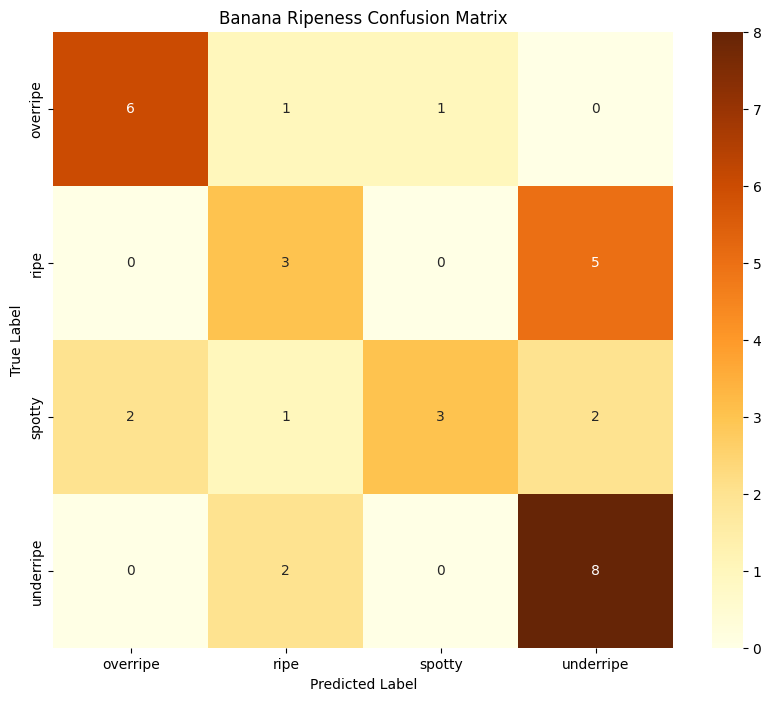


Classification Report:
              precision    recall  f1-score   support

    overripe       0.75      0.75      0.75         8
        ripe       0.43      0.38      0.40         8
      spotty       0.75      0.38      0.50         8
   underripe       0.53      0.80      0.64        10

    accuracy                           0.59        34
   macro avg       0.62      0.57      0.57        34
weighted avg       0.61      0.59      0.58        34



In [ ]:
def plot_confusion_matrix(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Banana Ripeness Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

plot_confusion_matrix(model, test_loader, train_data.classes)